In [10]:
from pathlib import Path
import xarray as xr
import numpy as np
import glob
import os

In [39]:
base_path = Path(os.getcwd())
repo_root = base_path.parents[2]
FOLDER = f'{repo_root}\\..\\sentinel_data\\S5P_Aerosol_Index'
nc_files = [f for f in os.listdir(FOLDER) if f.endswith('.nc')]
first_file = os.path.join(FOLDER, nc_files[0])
ds = xr.open_dataset(first_file)

In [40]:
print("=== DIMENSIONS ===")
for dim, size in ds.sizes.items():
    print(f"  {dim:10s}: {size:,}")

print("\n=== COORDINATES ===")
for name, coord in ds.coords.items():
    if name == 'time':
        print(f"  {name:10s}: {coord.values[0]} → {coord.values[-1]}  ({len(coord):,} steps)")
    else:
        print(f"  {name:10s}: {float(coord.min()):.4f} → {float(coord.max()):.4f}")

print("\n=== VARIABLES ===")
for name, var in ds.data_vars.items():
    print(f"  {name}")
    print(f"    shape  : {var.shape}")
    print(f"    dtype  : {var.dtype}")
    print(f"    dims   : {var.dims}")

print(f"\n=== SIZE ===")
print(f"  In-memory (uncompressed): {ds.nbytes / 1e9:.2f} GB")
print(f"  On-disk:                  {os.path.getsize(first_file) / 1e9:.2f} GB")
print(f"  Compression ratio:        {ds.nbytes / os.path.getsize(first_file):.1f}x")

=== DIMENSIONS ===
  time      : 3,918
  lon       : 593
  lat       : 255

=== COORDINATES ===
  time      : 2018-07-04T00:23:58.000000000 → 2019-04-09T23:29:25.000000000  (3,918 steps)
  lon       : 20.9465 → 26.8665
  lat       : 53.9063 → 56.4463

=== VARIABLES ===
  absorbing_aerosol_index
    shape  : (3918, 593, 255)
    dtype  : float32
    dims   : ('time', 'lon', 'lat')

=== SIZE ===
  In-memory (uncompressed): 2.37 GB
  On-disk:                  0.13 GB
  Compression ratio:        17.8x


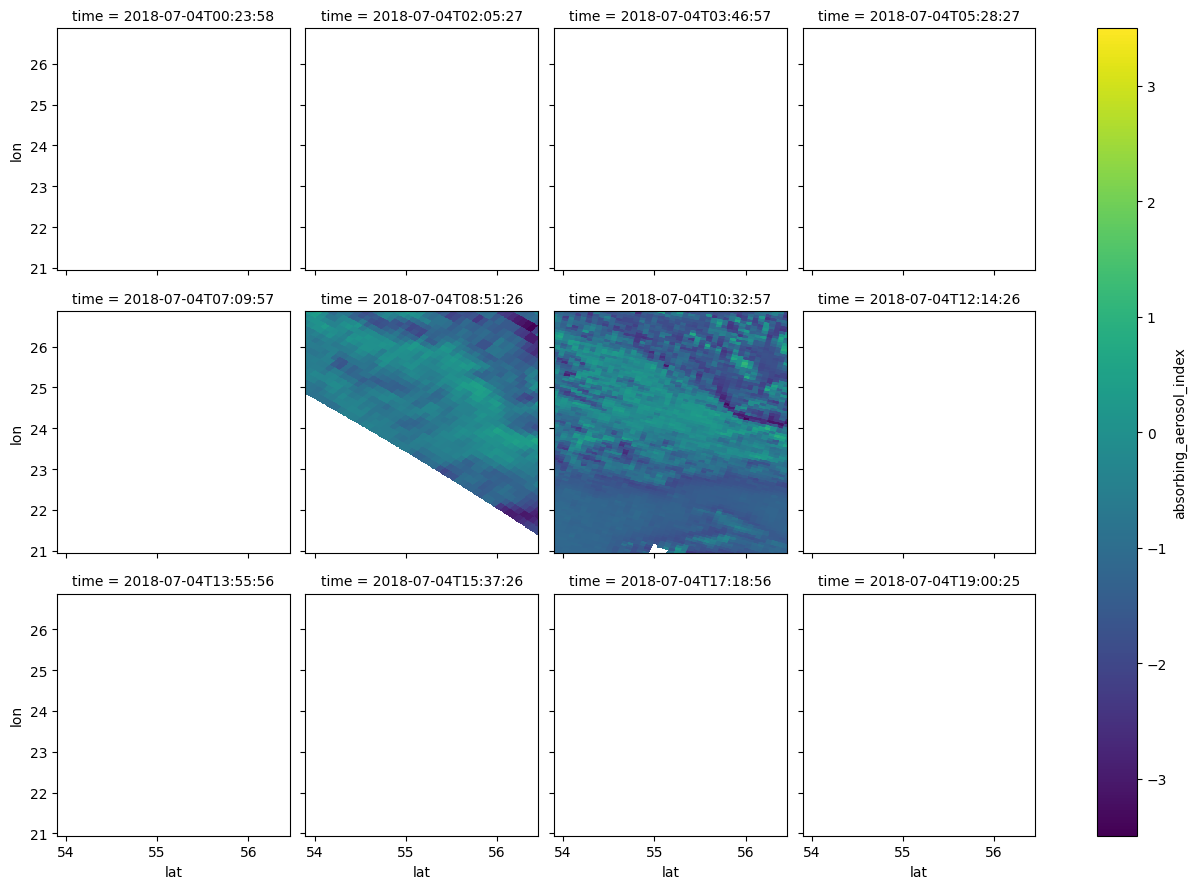

In [62]:
ds['absorbing_aerosol_index'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [55]:
mask = ~ds['absorbing_aerosol_index'].isnull().all(dim=['lat', 'lon'])
ds_filtered = ds.sel(time=mask)
print(f"Original time steps: {ds.time.size}")
print(f"Time steps with data: {ds_filtered.time.size}")

Original time steps: 3918
Time steps with data: 586


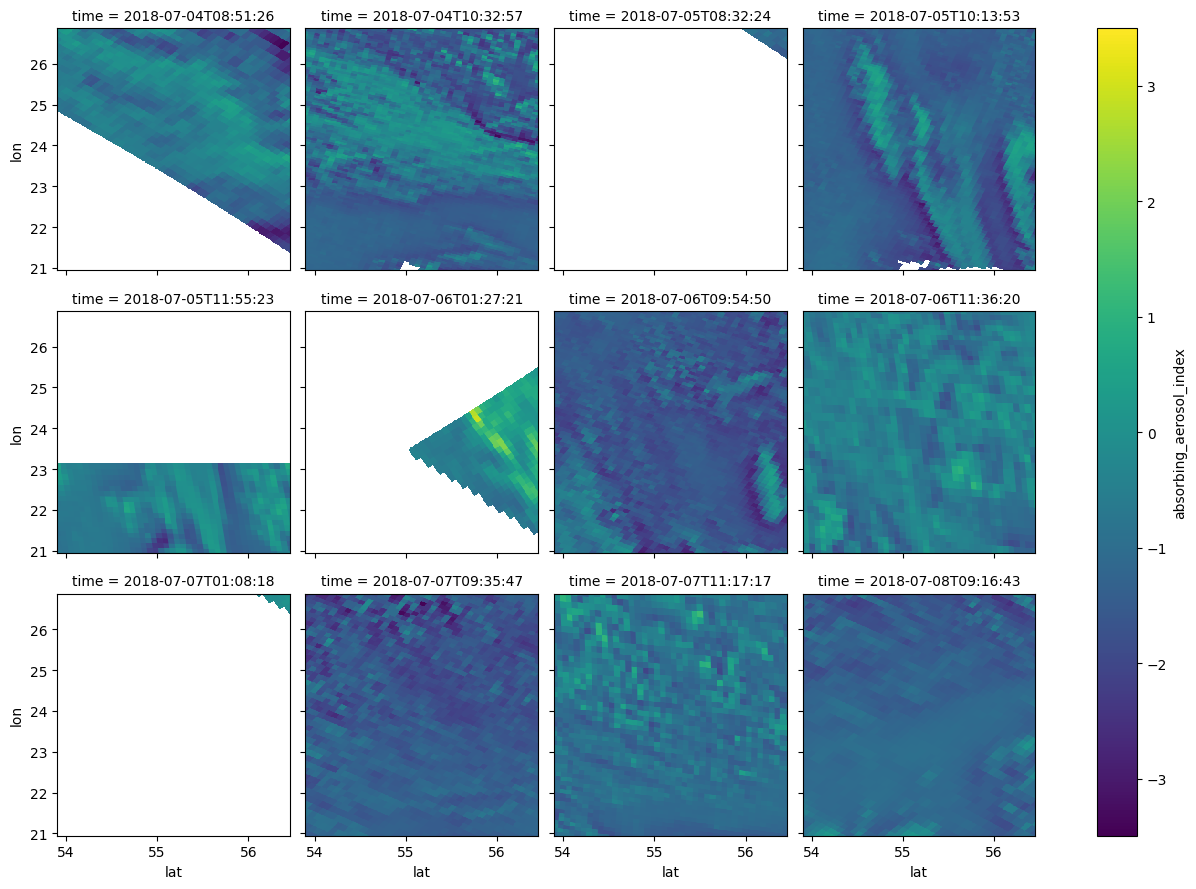

In [63]:
ds_filtered['absorbing_aerosol_index'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [57]:
daily_resampler = ds_filtered.resample(time='1D')
ds_daily = daily_resampler.mean()
print(f"Frames before: {ds_filtered.time.size}")
print(f"Days after:    {ds_daily.time.size}")

Frames before: 586
Days after:    280


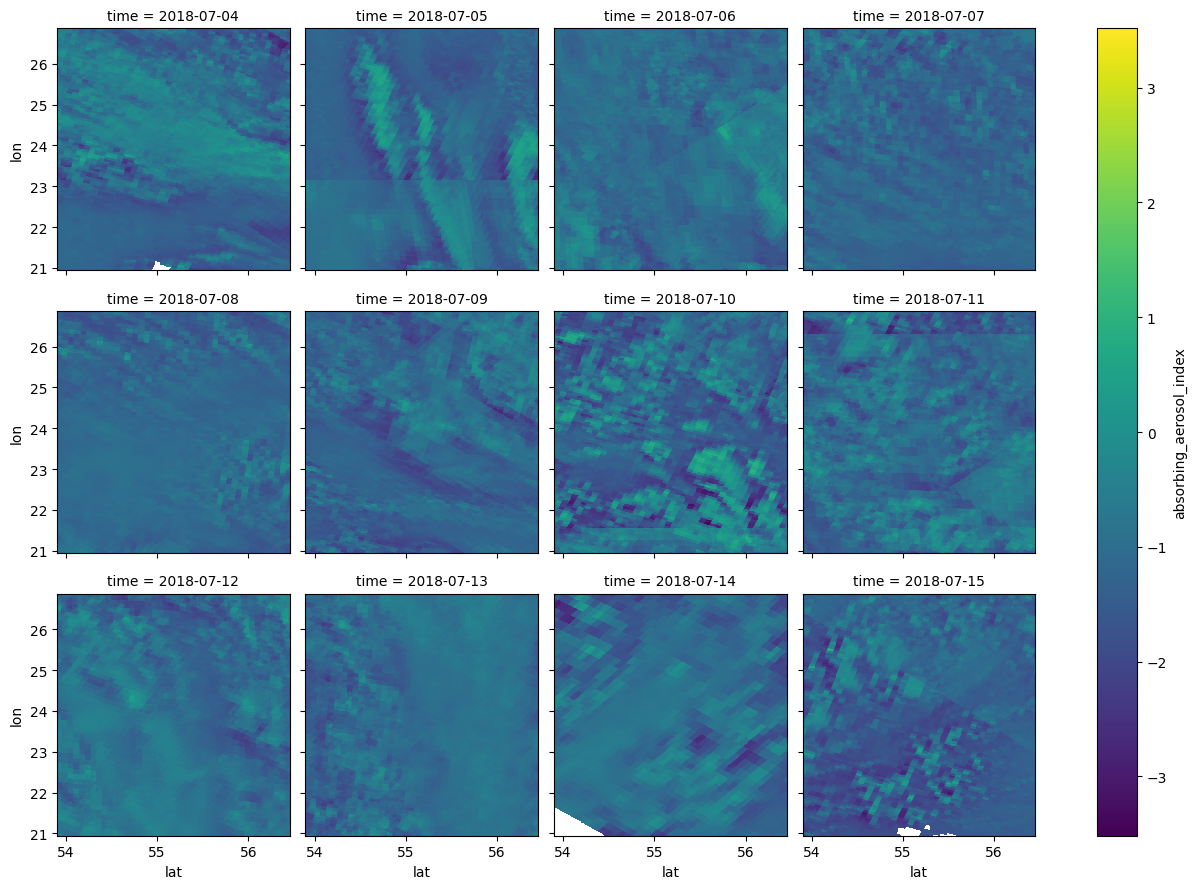

In [64]:
ds_daily['absorbing_aerosol_index'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

In [85]:
ds_compressed = ds_daily.coarsen(lat=15, lon=30, boundary='trim').mean()

In [ ]:
ds_compressed['absorbing_aerosol_index'].isel(time=slice(0, 12)).plot(col='time', col_wrap=4, cmap='viridis')

TypeError: No numeric data to plot.

In [88]:
vilnius_lon, vilnius_lat = 25.2797, 54.6872
ds_vilnius = ds_compressed.sel(lon=vilnius_lon, lat=vilnius_lat, method='nearest')
print(ds_vilnius)

<xarray.Dataset> Size: 3kB
Dimensions:                  (time: 280)
Coordinates:
  * time                     (time) datetime64[ns] 2kB 2018-07-04 ... 2019-04-09
    lon                      float64 8B 25.29
    lat                      float64 8B 54.73
Data variables:
    absorbing_aerosol_index  (time) float32 1kB -0.6793 0.2053 ... -0.3555
Attributes: (12/19)
    date_range:               [1530662400000 1647734400000]
    description:              <h3 id="offll3_aer_ai">OFFL/L3_AER_AI</h3><p>Th...
    keywords:                 ['aai', 'aerosol', 'air_quality', 'copernicus',...
    period:                   0
    product_tags:             ['tropomi', 'aerosol', 'aai', 'uvai', 'pollutio...
    provider:                 European Union/ESA/Copernicus
    ...                       ...
    visualization_0_bands:    absorbing_aerosol_index
    visualization_0_max:      1.5
    visualization_0_min:      -1.0
    visualization_0_name:     RGB
    visualization_0_palette:  black,blue,purple,c

In [98]:
ds_vilnius.to_dataframe().head()

,absorbing_aerosol_index,lon,lat
time,,,
2018-07-04,-0.679349,25.291513,54.726301
2018-07-05,0.205332,25.291513,54.726301
2018-07-06,-0.872028,25.291513,54.726301
2018-07-07,-1.232945,25.291513,54.726301
2018-07-08,-1.270795,25.291513,54.726301


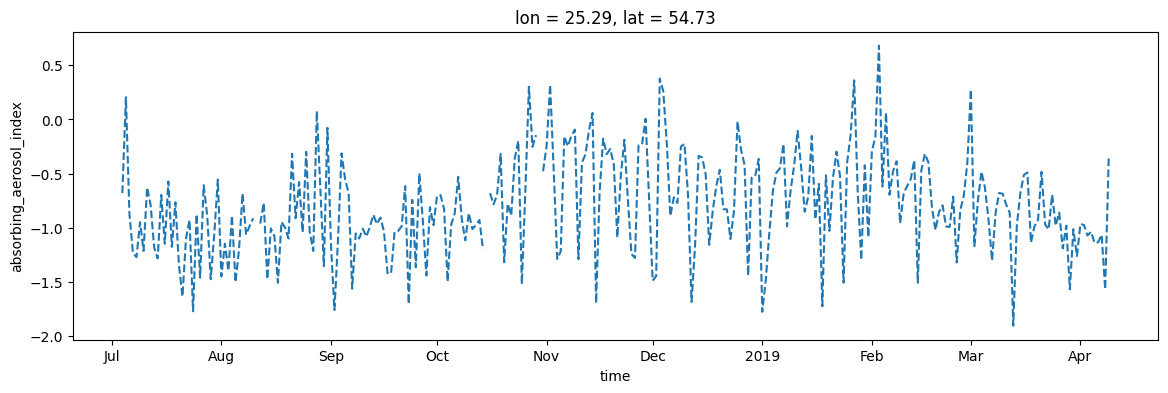

In [96]:
ds_vilnius['absorbing_aerosol_index'].plot(figsize=(14, 4), linestyle='--')

TypeError: Invalid shape () for image data

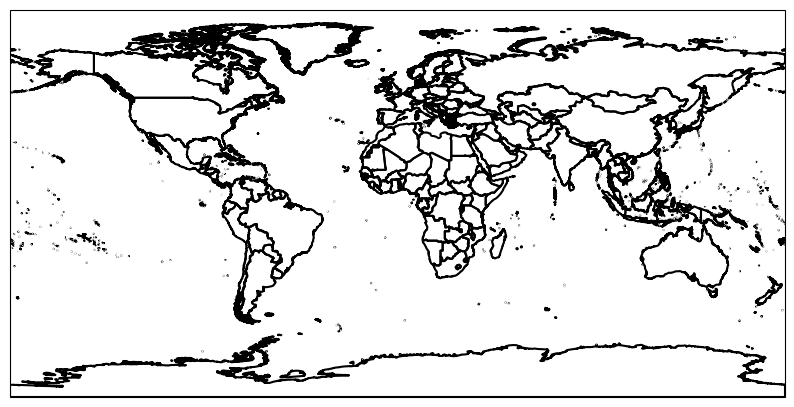

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

vilnius_lon, vilnius_lat = 25.2797, 54.6872
sample_frame = ds_compressed['absorbing_aerosol_index'].isel(time=0)

plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

countries = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_0_countries', scale='10m', facecolor='none'
)
ax.add_feature(countries, edgecolor='black', linewidth=1.5, zorder=3)

extent = [
    sample_frame.lon.min().item(), sample_frame.lon.max().item(),
    sample_frame.lat.min().item(), sample_frame.lat.max().item()
]

im = ax.imshow(
    sample_frame.values,
    extent=extent,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    origin='lower',
    zorder=1
)

ax.plot(vilnius_lon, vilnius_lat, 'ro', markersize=8, transform=ccrs.PlateCarree(), zorder=5)
ax.text(vilnius_lon + 0.1, vilnius_lat, 'Vilnius', transform=ccrs.PlateCarree(), 
        fontsize=12, fontweight='bold', zorder=5)

plt.colorbar(im, ax=ax, label='Aerosol Index', fraction=0.035, pad=0.04)

plt.title(f"Aerosol Index (10km) - Lithuania")
plt.show()